In [1]:
# import libraries
import pandas as pd
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn import tree

In [3]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
X = df[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']]
y = df['survived']

In [5]:
X = pd.get_dummies(X, columns=['sex'])

In [6]:
X.isnull().sum()

pclass          0
age           177
sibsp           0
parch           0
fare            0
sex_female      0
sex_male        0
dtype: int64

In [7]:
X.age.fillna(value=X['age'].mean(),inplace=True)

C:\Users\Hp\AppData\Local\Temp\ipykernel_9900\1520641283.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X.age.fillna(value=X['age'].mean(),inplace=True)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [9]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [10]:
y_pred = model.predict(X_test)

In [11]:
print("Accuracy: ", accuracy_score(y_test, y_pred))

Accuracy:  0.7597765363128491


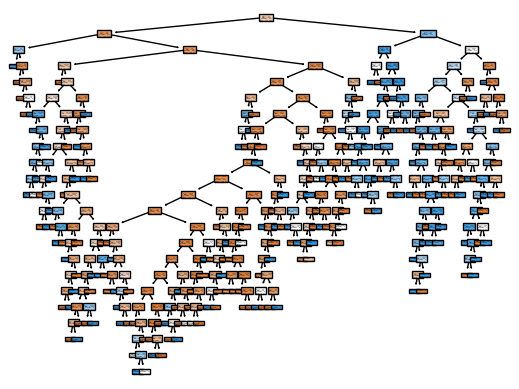

<Figure size 640x480 with 0 Axes>

In [12]:
tree.plot_tree(model.fit(X,y),filled=True)
plt.show()
plt.savefig("tree")

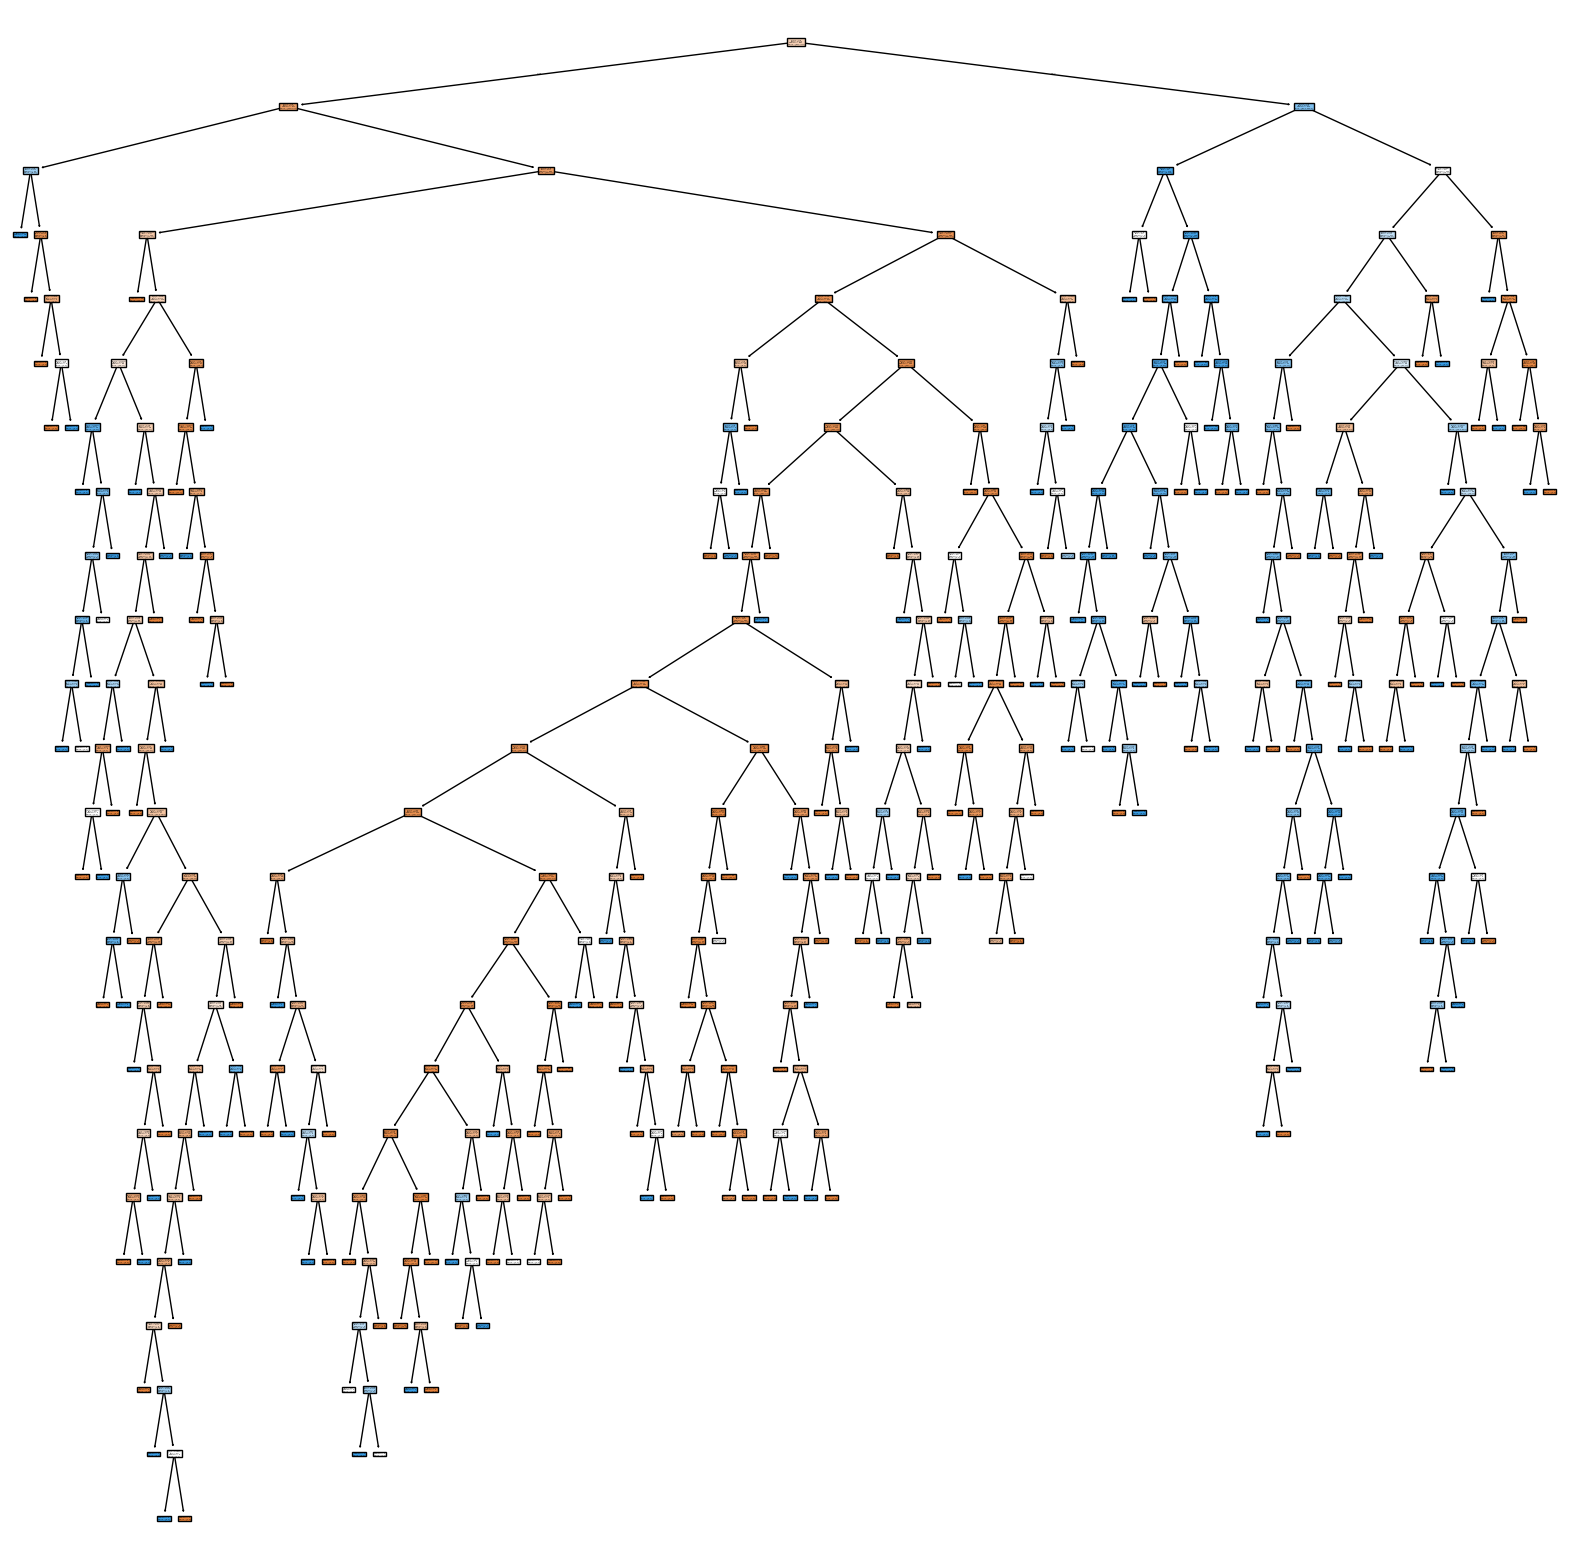

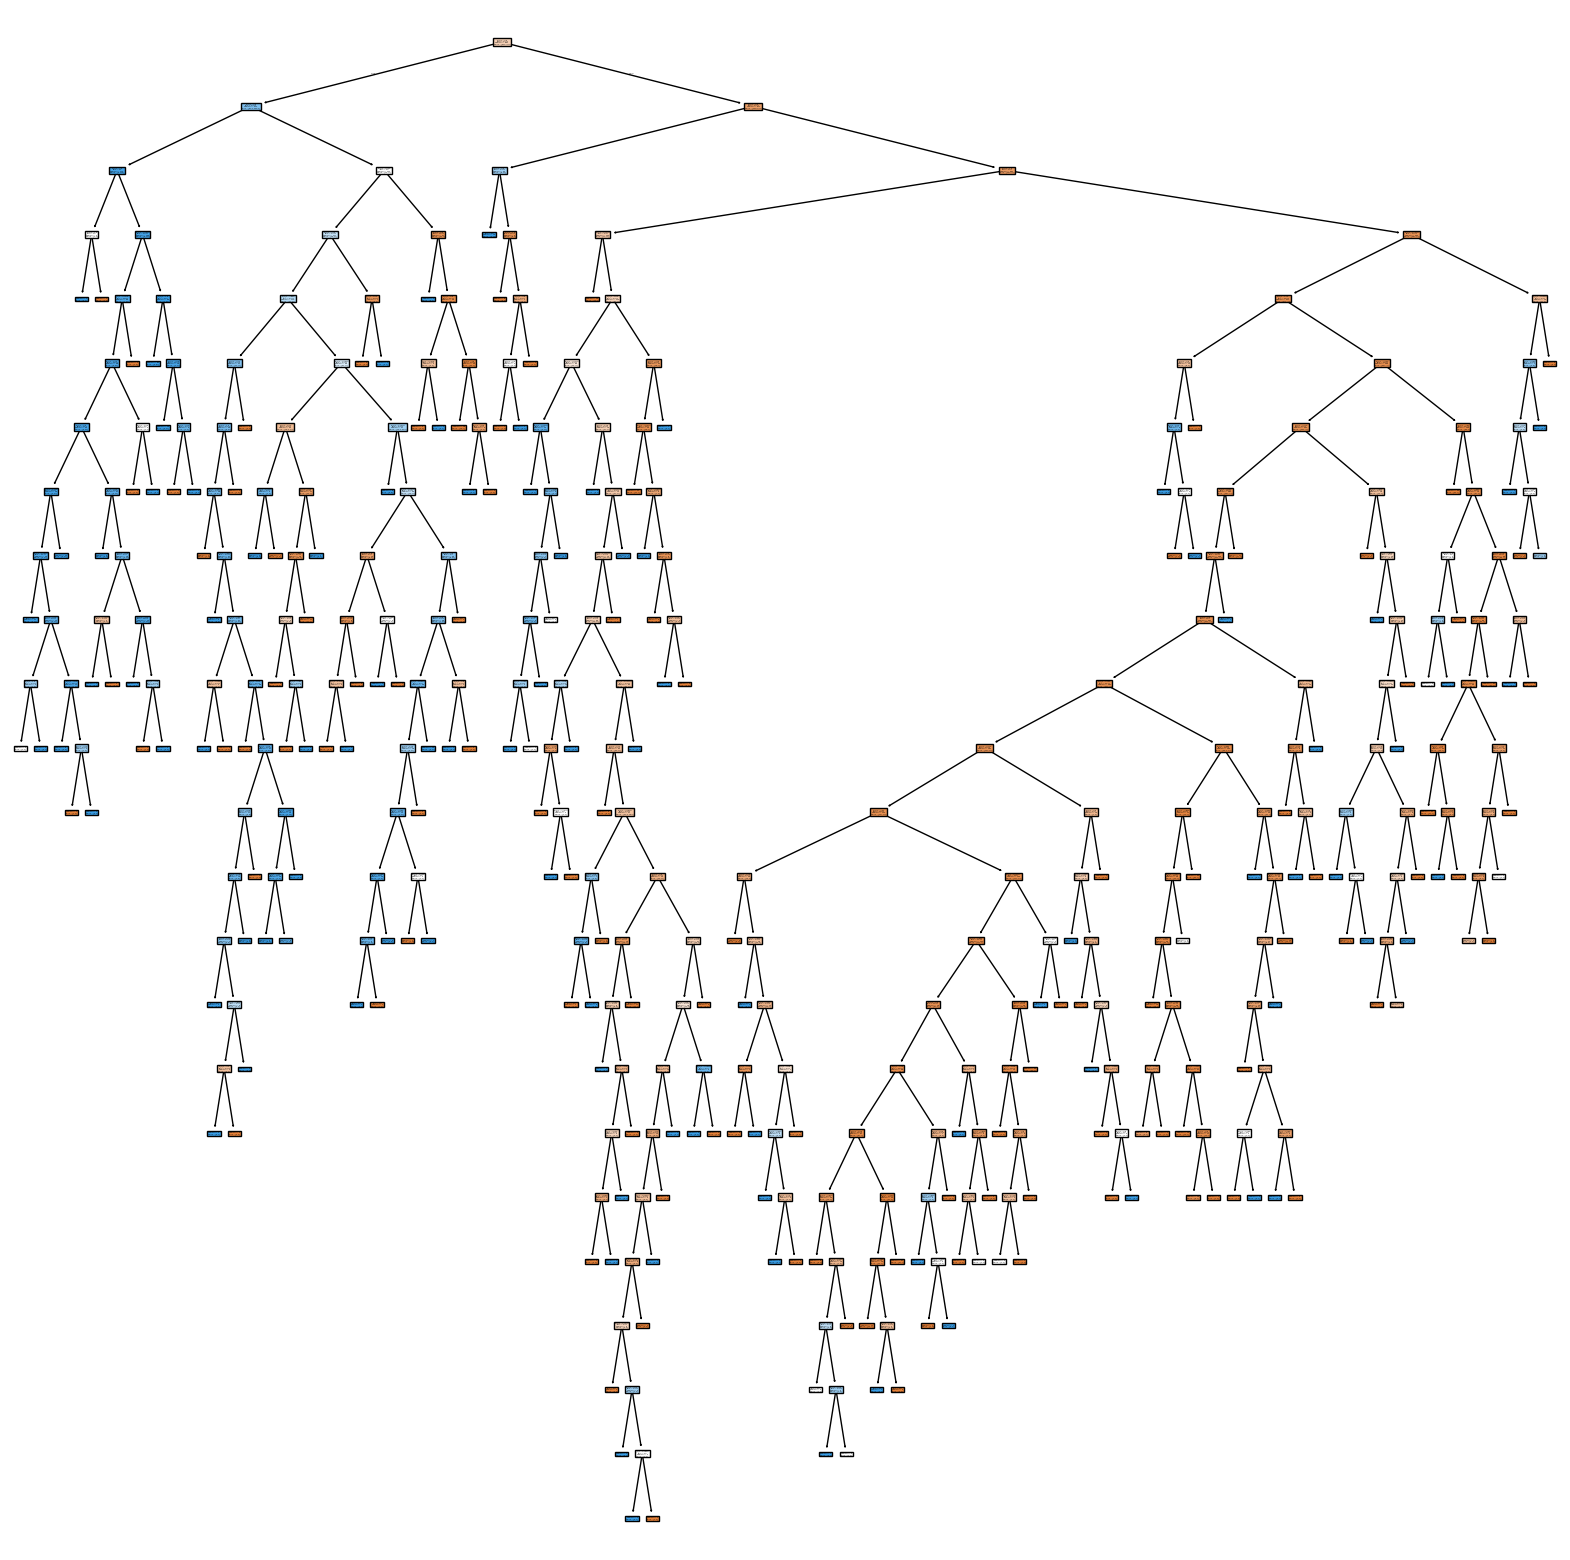

<Figure size 640x480 with 0 Axes>

In [14]:
plt.figure(figsize=(20, 20))
tree.plot_tree(model.fit(X, y), filled=True)
plt.savefig("decision_tree.pdf", format="pdf", dpi=300)
plt.show()
plt.figure(figsize=(20, 20))
tree.plot_tree(model.fit(X,y),filled=True)
plt.show()
plt.savefig("decission_tree.pdf", format="pdf",dpi = 300)

In [17]:
#Predictions

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

#Predictions
precision_score(y_test, y_pred)


0.7631578947368421

In [20]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

#Predictions
f1_score(y_test, y_pred) # harmonic mean of precission score and accuracy score

0.7295597484276729

In [19]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

#Predictions
recall_score(y_test, y_pred)

0.6987951807228916

These are the four most common classification evaluation metrics in Machine Learning. They are calculated from the confusion matrix.

1. Accuracy Score

Accuracy tells you how many predictions the model got correct out of all predictions.

Formula:

$$ Accuracy = \frac{TP + TN}{TP + TN + FP + FN} $$

Where:

TP = True Positive\
TN = True Negative\
FP = False Positive\
FN = False Negative

Example: If the model correctly predicts 90 out of 100 observations:

Accuracy = 90%

Best when: Classes are relatively balanced.

2. Precision Score

Precision tells you: "Of all the cases the model predicted as positive, how many were actually positive?"

Formula:

$$ Precision = \frac{TP}{TP + FP} $$

A high precision means few false positives.

Example: Model predicts 100 people as having a disease, but only 80 actually have it.

Precision = 80%

Important when: False positives are costly.

3. Recall Score

Recall tells you: "Of all the actual positive cases, how many did the model correctly identify?"

Formula:

$$ Recall = \frac{TP}{TP + FN} $$

A high recall means few false negatives.

Example: There are actually 100 people with a disease, and the model correctly identifies 90.

Recall = 90%

Important when: Missing a positive case is costly, such as disease detection.

4. F1 Score

F1 score combines Precision and Recall into a single metric using their harmonic mean.

Formula:

$$ F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall} $$

F1 is high only when both precision and recall are high.

Example:

Precision = 80%
Recall = 90%
$$ F1 \approx 84.7\% $$

Important when: You want a balance between precision and recall, especially with imbalanced datasets.

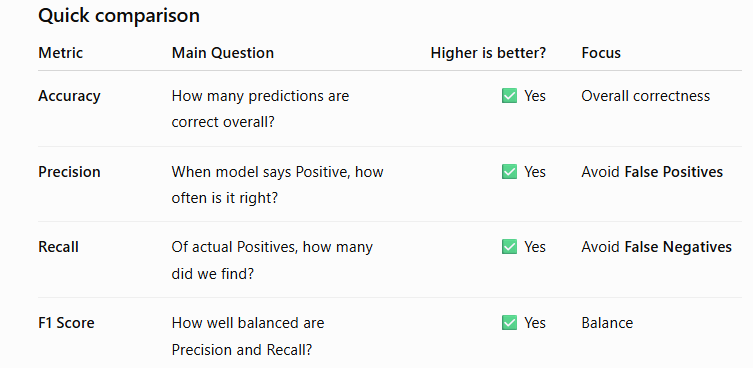